# 03. 업력 분류기 — 설정을 바꿔가며 비교

## 왜 하나

02 번에서 업력 분류기를 **한 가지 설정으로만** 만들었다. 94% 가 나왔지만,
**그게 좋은 건지 나쁜 건지 비교 대상이 없다.**

그래서 방식을 바꿔가며 여섯 번 돌려보고 표로 만든다.

| 실험 | 무엇을 바꾸나 |
| --- | --- |
| EXP-01 | 문장을 **단어 단위**로 자른다 (가장 단순한 기준선) |
| EXP-02 | 문장을 **글자 2~4개**로 자른다 (02 번에서 쓴 것) |
| EXP-03 | 개수 불균형 보정을 **끈다** |
| EXP-04 | 선 긋는 방식을 **다른 것**으로 바꾼다 (SVM) |
| EXP-05 | **애매하면 판단을 보류**한다 |
| EXP-06 | **「개월/년」 구분 힌트**를 준다 (02 번에서 찾은 약점 보완) |

전부 그래픽카드 없이 몇 초씩이면 끝난다.

## 공정하게 비교하려면

- **같은 문제집, 같은 시험지**를 쓴다. 나누는 주사위 눈금(SEED)을 고정한다.
- 시험지는 83장뿐이라 운이 섞인다. 그래서 **교차검증**을 같이 본다 —
  공부용 249장을 5조각으로 나눠, 4조각으로 배우고 1조각으로 시험 보기를
  5번 돌려 평균을 낸다. 한 번 재는 것보다 흔들림이 적다.

In [1]:
# -*- coding: utf-8 -*-
import io, os, sys, json, re, time, collections

# 어디서 띄우든 작업 폴더를 data-collection 으로 맞춘다.
ROOT = os.getcwd()
while not all(os.path.isdir(os.path.join(ROOT, d)) for d in ('eval', 'ml')):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise SystemExit('data-collection 폴더를 찾지 못했다. 저장소 안에서 실행한다.')
    ROOT = parent
os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

DATA = os.path.join(ROOT, 'ml', 'data')
os.makedirs(DATA, exist_ok=True)
print('작업 폴더 :', os.getcwd())

작업 폴더 : C:\SKN-TEST\SKN32-FINAL-1TEAM\data-collection


### 데이터 준비

01 번이 만든 라벨 파일을 읽는다. 없으면 EC2 DB 에서 다시 만든다.

In [2]:
LABELS = os.path.join(DATA, 'age_labels.jsonl')

if not os.path.exists(LABELS):
    print('라벨 파일이 없다. EC2 DB 에서 다시 만든다...')
    from shared import store_mysql
    cur = store_mysql.connect().cursor()
    cur.execute('''SELECT notice_id, age_source_quote, age_years_max,
                          age_years_min, no_age_limit
                     FROM notice_conditions
                    WHERE age_source_quote IS NOT NULL AND age_source_quote <> '' ''')
    with io.open(LABELS, 'w', encoding='utf-8') as f:
        for nid, quote, ymax, ymin, nolimit in cur.fetchall():
            f.write(json.dumps({
                'notice_id': nid,
                'quote': ' '.join(str(quote).split()),
                'label': 1 if (ymax is not None or ymin is not None or nolimit) else 0,
            }, ensure_ascii=False) + '\n')

rows = [json.loads(l) for l in io.open(LABELS, encoding='utf-8') if l.strip()]
texts = [r['quote'] for r in rows]
labels = [r['label'] for r in rows]
print('문장 %d개 · 업력 %d · 아님 %d' % (len(rows), sum(labels), len(labels) - sum(labels)))

문장 332개 · 업력 130 · 아님 202


In [3]:
from sklearn.model_selection import train_test_split

SEED = 20260916      # 02 번과 같은 눈금. 같은 문제집·시험지를 써야 비교가 된다

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.25, stratify=labels, random_state=SEED)

print('공부용 %d · 시험용 %d' % (len(X_train), len(X_test)))
print('공부용 업력 비율 %.1f%% · 시험용 %.1f%%'
      % (sum(y_train) / len(y_train) * 100, sum(y_test) / len(y_test) * 100))

공부용 249 · 시험용 83
공부용 업력 비율 39.0% · 시험용 39.8%


---

## EXP-06 에 쓸 「단위 힌트」

02 번에서 이런 약점을 찾았다 —

> 학습 데이터에 **「N개월 이상」 형태 40건이 모두 「업력 아님」** 으로 들어 있어서,
> 모델이 **「이상」 이라는 말 자체를 업력이 아닌 신호로** 잘못 배웠다.
> 그래서 「업력이 2년 이상」 같은 진짜 업력 조건까지 놓쳤다.

고치는 방법은 **모델이 헷갈리는 구분을 대신 찍어주는 것**이다.
문장 뒤에 표시를 붙여서 「개월」과 「년」, 「이상」과 「이내」를 구별하게 한다.

```
"3개월 이상 영업 중인 소상공인"   →  "3개월 이상 … __개월하한__"
"업력이 2년 이상이며"             →  "업력이 2년 이상이며 __년하한__"
"창업 후 7년 이내"                →  "창업 후 7년 이내 __년상한__"
```

사람이 도메인 지식을 넣어주는 것이라 **특징 공학(feature engineering)** 이라 부른다.

In [4]:
HINTS = [
    (r'\d+\s*년\s*(이내|미만|이하)',   '__년상한__'),
    (r'\d+\s*년\s*(이상|초과|경과)',   '__년하한__'),
    (r'\d+\s*개월\s*(이상|초과)',      '__개월하한__'),
    (r'\d+\s*개월\s*(이내|미만)',      '__개월상한__'),
    (r'만\s*\d+\s*세',                '__사람나이__'),
    (r'(재직|근속|근무)',              '__근속__'),
    (r'(창업|설립|개업|사업자등록)',    '__창업어휘__'),
]

def add_hints(text):
    marks = [tag for pattern, tag in HINTS if re.search(pattern, text)]
    return text + ' ' + ' '.join(marks) if marks else text

# 붙은 표시가 라벨과 얼마나 맞물리는지 먼저 확인한다
print('%-14s %6s %6s   %s' % ('표시', '업력', '아님', '업력 비율'))
print('-' * 46)
for pattern, tag in HINTS:
    hit = [(t, l) for t, l in zip(texts, labels) if re.search(pattern, t)]
    if hit:
        pos = sum(l for _, l in hit)
        print('%-14s %6d %6d   %5.1f%%' % (tag, pos, len(hit) - pos, pos / len(hit) * 100))

print()
print('예시:', add_hints('업력이 2년 이상이며 최근 6개월 매출 감소')[:70])

표시                 업력     아님   업력 비율
----------------------------------------------
__년상한__            83     55    60.1%
__년하한__            42     72    36.8%
__개월하한__            2     41     4.7%
__개월상한__            1      6    14.3%
__사람나이__            1      2    33.3%
__근속__              0      8     0.0%
__창업어휘__           95     60    61.3%

예시: 업력이 2년 이상이며 최근 6개월 매출 감소 __년하한__


---

## 여섯 가지 실험 정의

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline

def word_tfidf():
    return TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=2, sublinear_tf=True)

def char_tfidf():
    return TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), min_df=2, sublinear_tf=True)

def lr(balanced=True):
    return LogisticRegression(max_iter=2000, C=1.0,
                              class_weight='balanced' if balanced else None)

EXPERIMENTS = [
    ('EXP-01', '단어 단위 + 로지스틱 회귀 (기준선)',
     lambda: make_pipeline(word_tfidf(), lr()), None, None),
    ('EXP-02', '글자 2~4개 + 로지스틱 회귀 (02번에서 쓴 것)',
     lambda: make_pipeline(char_tfidf(), lr()), None, None),
    ('EXP-03', '글자 2~4개 + 불균형 보정 끔',
     lambda: make_pipeline(char_tfidf(), lr(balanced=False)), None, None),
    ('EXP-04', '글자 2~4개 + 선형 SVM',
     lambda: make_pipeline(char_tfidf(), LinearSVC(class_weight='balanced')), None, None),
    ('EXP-05', 'EXP-02 + 애매하면 판단 보류 (0.35~0.65)',
     lambda: make_pipeline(char_tfidf(), lr()), (0.35, 0.65), None),
    ('EXP-06', 'EXP-02 + 개월/년 단위 힌트',
     lambda: make_pipeline(char_tfidf(), lr()), None, add_hints),
]

print('실험 %d개' % len(EXPERIMENTS))
for name, desc, _, abstain, prep in [(e[0], e[1], None, e[2], e[3]) for e in EXPERIMENTS]:
    print('  %s  %s' % (name, desc))

실험 6개
  EXP-01  단어 단위 + 로지스틱 회귀 (기준선)
  EXP-02  글자 2~4개 + 로지스틱 회귀 (02번에서 쓴 것)
  EXP-03  글자 2~4개 + 불균형 보정 끔
  EXP-04  글자 2~4개 + 선형 SVM
  EXP-05  EXP-02 + 애매하면 판단 보류 (0.35~0.65)
  EXP-06  EXP-02 + 개월/년 단위 힌트


---

## 실행

**지표 읽는 법** (업력이라고 판단한 것 기준)

| 이름 | 뜻 | 낮으면 |
| --- | --- | --- |
| 정밀도 | 업력이라 한 것 중 진짜 업력 비율 | 엉뚱한 걸 업력으로 읽어 **잘못된 자격 판정** |
| 재현율 | 진짜 업력 중 찾아낸 비율 | 업력을 놓쳐서 **판정을 못 함** |
| F1 | 둘의 균형 | |
| 적용률 | 판단을 내린 비율 (보류 제외) | 보류가 많으면 낮아진다 |

이 프로젝트에서는 **정밀도가 더 중요하다.** 놓치면 「확인 필요」로 남기면 되지만,
잘못 읽으면 사용자에게 틀린 자격 판정을 보여주게 된다.

In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

def scores(truth, pred):
    p, r, f, _ = precision_recall_fscore_support(
        truth, pred, labels=[1], zero_division=0, average='binary')
    return accuracy_score(truth, pred), p, r, f

def run_one(build, abstain, prep):
    tr = [prep(t) for t in X_train] if prep else X_train
    te = [prep(t) for t in X_test] if prep else X_test

    # ① 교차검증 — 공부용 249장을 5조각으로 나눠 5번 재고 평균
    cv_f1 = []
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    tr_arr, y_arr = np.array(tr, dtype=object), np.array(y_train)
    for fit_idx, val_idx in kf.split(tr_arr, y_arr):
        m = build()
        m.fit(list(tr_arr[fit_idx]), list(y_arr[fit_idx]))
        _, _, _, f = scores(list(y_arr[val_idx]), m.predict(list(tr_arr[val_idx])))
        cv_f1.append(f)

    # ② 시험지 83장
    t0 = time.time()
    model = build()
    model.fit(tr, y_train)
    fit_sec = time.time() - t0

    truth, pred = list(y_test), list(model.predict(te))
    coverage = 1.0
    if abstain and hasattr(model, 'predict_proba'):
        low, high = abstain
        proba = model.predict_proba(te)[:, 1]
        keep = [i for i, p in enumerate(proba) if not (low <= p <= high)]
        coverage = len(keep) / len(te)
        truth = [y_test[i] for i in keep]
        pred = [1 if proba[i] > high else 0 for i in keep]

    acc, p, r, f1 = scores(truth, pred)
    return {'cv_f1_mean': float(np.mean(cv_f1)), 'cv_f1_std': float(np.std(cv_f1)),
            'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1,
            'coverage': coverage, 'fit_sec': fit_sec, 'model': model}

results = []
for name, desc, build, abstain, prep in EXPERIMENTS:
    out = run_one(build, abstain, prep)
    out.update({'exp': name, 'desc': desc})
    results.append(out)
    print('%s  F1 %.3f (CV %.3f±%.3f) · 정밀도 %.3f · 재현율 %.3f · 적용률 %.0f%% · %.1f초'
          % (name, out['f1'], out['cv_f1_mean'], out['cv_f1_std'],
             out['precision'], out['recall'], out['coverage'] * 100, out['fit_sec']))

EXP-01  F1 0.820 (CV 0.840±0.028) · 정밀도 0.893 · 재현율 0.758 · 적용률 100% · 0.0초
EXP-02  F1 0.921 (CV 0.806±0.023) · 정밀도 0.967 · 재현율 0.879 · 적용률 100% · 0.0초
EXP-03  F1 0.786 (CV 0.769±0.082) · 정밀도 0.957 · 재현율 0.667 · 적용률 100% · 0.0초
EXP-04  F1 0.875 (CV 0.833±0.045) · 정밀도 0.903 · 재현율 0.848 · 적용률 100% · 0.0초
EXP-05  F1 0.929 (CV 0.806±0.023) · 정밀도 0.929 · 재현율 0.929 · 적용률 54% · 0.0초
EXP-06  F1 0.794 (CV 0.797±0.026) · 정밀도 0.771 · 재현율 0.818 · 적용률 100% · 0.0초


---

## 결과표

**「학습 결과서」 3.2 실험 결과 비교 표에 그대로 들어갈 내용이다.**

In [7]:
# 고르는 기준을 먼저 정해두고 그대로 따른다 (결과를 보고 기준을 바꾸지 않는다).
#   후보  : 적용률 100% 인 것만. 보류를 쓰는 EXP-05 는 판단 건수가 달라 나란히 못 둔다
#   1순위 : 정밀도 — 이 프로젝트는 「잘못 말하지 않는 것」이 「많이 말하는 것」보다 중요하다
#   동률  : F1
full = [r for r in results if r['coverage'] >= 0.999]
best = max(full, key=lambda r: (round(r['precision'], 3), r['f1']))

print('%-8s %-34s %-8s %-14s %-8s %-8s %-7s'
      % ('실험', '설정', 'F1', '교차검증 F1', '정밀도', '재현율', '적용률'))
print('-' * 96)
for r in results:
    mark = ' ← 선택' if r is best else ''
    print('%-8s %-34s %-8.3f %-14s %-8.3f %-8.3f %-6.0f%%%s'
          % (r['exp'], r['desc'][:33], r['f1'],
             '%.3f±%.3f' % (r['cv_f1_mean'], r['cv_f1_std']),
             r['precision'], r['recall'], r['coverage'] * 100, mark))
print()
print('선택 : %s — %s' % (best['exp'], best['desc']))
print('       (적용률 100%% 중 정밀도 최고: %.3f)' % best['precision'])
print()
print('※ EXP-05 는 F1 이 가장 높아 보이지만 **판단을 절반만** 한다(적용률 54%).')
print('   전부 판단한 것과 나란히 비교할 수 없다. 서비스에 켜고 끄는 선택지로 따로 본다.')

실험       설정                                 F1       교차검증 F1        정밀도      재현율      적용률    
------------------------------------------------------------------------------------------------
EXP-01   단어 단위 + 로지스틱 회귀 (기준선)              0.820    0.840±0.028    0.893    0.758    100   %
EXP-02   글자 2~4개 + 로지스틱 회귀 (02번에서 쓴 것)      0.921    0.806±0.023    0.967    0.879    100   % ← 선택
EXP-03   글자 2~4개 + 불균형 보정 끔                 0.786    0.769±0.082    0.957    0.667    100   %
EXP-04   글자 2~4개 + 선형 SVM                   0.875    0.833±0.045    0.903    0.848    100   %
EXP-05   EXP-02 + 애매하면 판단 보류 (0.35~0.65)    0.929    0.806±0.023    0.929    0.929    54    %
EXP-06   EXP-02 + 개월/년 단위 힌트                0.794    0.797±0.026    0.771    0.818    100   %

선택 : EXP-02 — 글자 2~4개 + 로지스틱 회귀 (02번에서 쓴 것)
       (적용률 100% 중 정밀도 최고: 0.967)

※ EXP-05 는 F1 이 가장 높아 보이지만 **판단을 절반만** 한다(적용률 54%).
   전부 판단한 것과 나란히 비교할 수 없다. 서비스에 켜고 끄는 선택지로 따로 본다.


### ⚠ 교차검증과 시험지가 다른 말을 한다

표를 보면 두 숫자의 순위가 어긋난다. 이건 **데이터가 적다는 신호**다.

```
교차검증 F1 (249장을 5번 나눠 잼)   EXP-01 이 가장 높다
시험지 F1  (83장 한 번 잼)          EXP-02 가 가장 높다
```

시험지가 83장뿐이라 **한 번 재면 운이 섞인다.** 교차검증의 ±(0.02~0.08)보다
작은 차이는 우연으로 봐야 한다.

**확실하게 말할 수 있는 것은 두 가지뿐이다.**

- EXP-03(불균형 보정 끔)은 **재현율이 뚜렷하게 낮다** — 보정은 켜는 게 맞다
- 나머지 차이는 흔들림 범위 안이라 **순위를 단정할 수 없다**

이럴 때는 숫자 하나로 고르지 말고 **미리 정한 기준**(정밀도 우선)을 따르는 것이 맞다.

### EXP-02 와 EXP-06 비교 — 약점이 고쳐졌나

02 번에서 찾은 문제는 **「N년 이상」 형태를 업력이 아니라고 판단하는 것**이었다.
힌트를 준 EXP-06 이 그 부분에서 실제로 나아졌는지 따로 확인한다.

In [8]:
target = re.compile(r'\d+\s*년\s*(이상|초과|경과)')
idx = [i for i, t in enumerate(X_test) if target.search(t)]

if not idx:
    print('시험지에 「N년 이상」 문장이 없다.')
else:
    print('시험지 중 「N년 이상」 이 들어간 문장 %d개' % len(idx))
    print()
    for exp in ('EXP-02', 'EXP-06'):
        r = next(x for x in results if x['exp'] == exp)
        prep = add_hints if exp == 'EXP-06' else None
        te = [prep(X_test[i]) for i in idx] if prep else [X_test[i] for i in idx]
        pred = r['model'].predict(te)
        truth = [y_test[i] for i in idx]
        ok = sum(1 for a, b in zip(truth, pred) if a == b)
        print('%s  %d/%d 맞음 (%.0f%%)' % (exp, ok, len(idx), ok / len(idx) * 100))
    print()
    r2 = next(x for x in results if x['exp'] == 'EXP-02')
    r6 = next(x for x in results if x['exp'] == 'EXP-06')
    for i in idx:
        p2 = r2['model'].predict([X_test[i]])[0]
        p6 = r6['model'].predict([add_hints(X_test[i])])[0]
        if p2 != p6:
            mark = lambda v: '업력' if v else '아님'
            print('정답 %s · EXP-02 %s · EXP-06 %s'
                  % (mark(y_test[i]), mark(p2), mark(p6)))
            print('   ', X_test[i][:70])

시험지 중 「N년 이상」 이 들어간 문장 30개

EXP-02  26/30 맞음 (87%)
EXP-06  23/30 맞음 (77%)

정답 업력 · EXP-02 업력 · EXP-06 아님
    접수마감일 기준 창업 후 1년이상 경과하고 6개월 이상 납세 등 창원에서 업력이 있는 기업
정답 아님 · EXP-02 아님 · EXP-06 업력
    사업자등록 1년 경과(서류 접수일 기준)된 관내 중소기업 및 소상공인
정답 아님 · EXP-02 아님 · EXP-06 업력
    군포시 관내 사업자등록 후 1년 이상 운영중인 중소제조기업


---

## 그림 — 실험별 성능

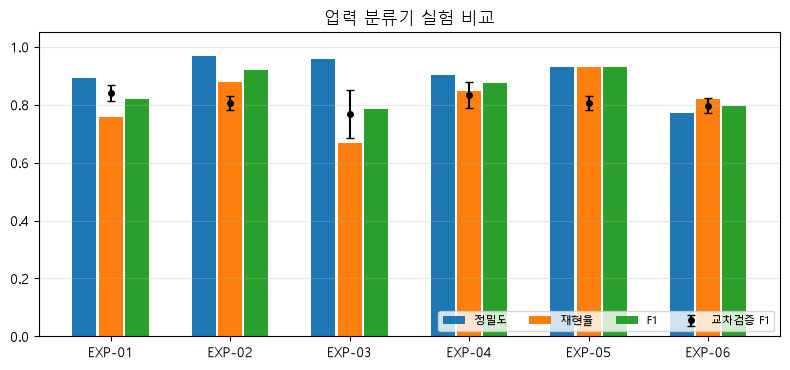

In [9]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt

names = [r['exp'] for r in results]
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(x - 0.22, [r['precision'] for r in results], 0.2, label='정밀도')
ax.bar(x, [r['recall'] for r in results], 0.2, label='재현율')
ax.bar(x + 0.22, [r['f1'] for r in results], 0.2, label='F1')
ax.errorbar(x, [r['cv_f1_mean'] for r in results],
            yerr=[r['cv_f1_std'] for r in results],
            fmt='o', color='black', markersize=4, capsize=3, label='교차검증 F1')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 1.05); ax.grid(axis='y', alpha=.3)
ax.legend(ncol=4, fontsize=8, loc='lower right')
ax.set_title('업력 분류기 실험 비교')
fig.tight_layout()
fig.savefig(os.path.join(DATA, 'ml_experiments.png'), dpi=150)
plt.show()

---

## 최종 모델 저장

F1 이 가장 높은 설정으로 **전체 332개를 다 써서** 다시 학습해 저장한다.
비교는 끝났으니 이제 데이터를 아낄 이유가 없다.

In [10]:
import joblib

MODELS = os.path.join(ROOT, 'ml', 'models')
os.makedirs(MODELS, exist_ok=True)

chosen = next(e for e in EXPERIMENTS if e[0] == best['exp'])
_, desc, build, abstain, prep = chosen
final = build()
final.fit([prep(t) for t in texts] if prep else texts, labels)

path = os.path.join(MODELS, 'age_classifier_v2.joblib')
joblib.dump({'model': final, 'uses_hints': prep is not None,
             'abstain': abstain, 'exp': best['exp'], 'seed': SEED}, path)
print('저장 → %s (%.1f KB)' % (path, os.path.getsize(path) / 1024))
print('선택된 설정 : %s — %s' % (best['exp'], desc))

for s in ['창업 후 5년 이내 중소기업', '업력이 2년 이상인 기업',
          '장기재직 3년 이상 근로자', '6개월 이상 영업 중인 소상공인']:
    q = prep(s) if prep else s
    p = final.predict_proba([q])[0][1] if hasattr(final, 'predict_proba') else float(final.predict([q])[0])
    print('  %-28s → 업력일 확률 %.0f%%' % (s, p * 100))

저장 → C:\SKN-TEST\SKN32-FINAL-1TEAM\data-collection\ml\models\age_classifier_v2.joblib (95.6 KB)
선택된 설정 : EXP-02 — 글자 2~4개 + 로지스틱 회귀 (02번에서 쓴 것)
  창업 후 5년 이내 중소기업              → 업력일 확률 81%
  업력이 2년 이상인 기업                → 업력일 확률 57%
  장기재직 3년 이상 근로자               → 업력일 확률 25%
  6개월 이상 영업 중인 소상공인            → 업력일 확률 18%


In [11]:
out = os.path.join(DATA, 'ml_experiments.json')
json.dump({
    'seed': SEED, 'n_total': len(rows), 'n_train': len(X_train), 'n_test': len(X_test),
    'chosen': best['exp'],
    'experiments': [{k: v for k, v in r.items() if k != 'model'} for r in results],
}, io.open(out, 'w', encoding='utf-8'), ensure_ascii=False, indent=1)
print('저장 →', out)

저장 → C:\SKN-TEST\SKN32-FINAL-1TEAM\data-collection\ml\data\ml_experiments.json


---

## 정리

만들어진 것

- `ml/models/age_classifier_v2.joblib` — 비교 끝에 고른 최종 모델
- `ml/data/ml_experiments.json` — 실험 결과 (문서에 넣을 표)
- `ml/data/ml_experiments.png` — 비교 그림

**결과를 어떻게 읽든 결과서에 쓸 수 있다.**

| 나온 결과 | 쓸 내용 |
| --- | --- |
| EXP-06 이 가장 좋다 | 오류 분석으로 약점을 찾아 특징 공학으로 해결했다 |
| EXP-02 와 비슷하다 | 힌트가 도움이 되지 않았다. 데이터가 이미 그 정보를 담고 있었다 |
| 오히려 나빠졌다 | 힌트가 잡음이 되었다. 규칙을 손으로 넣는 것의 한계 |

교차검증의 ± 보다 작은 차이는 **우연일 수 있다.** 그 점을 같이 적는다.